## Slides RL 4 - Training Animations


In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path
import os

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

In [3]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)


def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [4]:
# HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'

In [5]:
VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space

In [6]:
CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.07

def draw_cartpole(ax, cart_x, pole_theta, action=None):
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-0.55, 1.75)
    ax.set_aspect('equal'); ax.axis('off')
    ax.plot([-2.4, 2.4], [0, 0], color=CHILL_BROWN, lw=1.5, zorder=1)   # track
    cart_y = WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, WHEEL_R), WHEEL_R, color=CHILL_BROWN, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc='#3a3a3a', ec=CHILL_BROWN, lw=1.5, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color='w', lw=6, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.045, color=CHILL_BROWN, zorder=6))
    if action is not None:   # action arrow under the cart, your color convention
        ax.scatter([cart_x], [-0.32],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=420,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)

In [7]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

ANG_LIM = (-13, 13) #Ok I want this to be in degrees!
VEL_LIM = (-17, 17)   # angvel data is pre-divided by VEL_SCALE=10

## 0. Some setup and baselines

In [8]:
class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity.

    P(right) = sigmoid(logit). Returns [P(left), P(right)] with shape (2,) or (T, 2),
    so the REINFORCE loop below is unchanged from the neural net version.
    """
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        feats = x[..., 2:4]                # state indices 2, 3: pole angle, pole angular velocity
        logit = feats @ self.theta         # scalar or (T,)
        p_right = torch.sigmoid(logit)
        return torch.stack([1.0 - p_right, p_right], dim=-1)

In [9]:
# # This might be cleaner scaling wise, but I have a good amount of tech debt doing it the other way
# # let me see if I can get the job done w/o this. 

# class Pi(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.theta = nn.Parameter(torch.zeros(2))

#     def forward(self, x):
#         feats = x[..., 2:4] * (180 / np.pi)   # degree-scale features
#         logit = feats @ self.theta
#         p_right = torch.sigmoid(logit)
#         return torch.stack([1.0 - p_right, p_right], dim=-1)

In [10]:
def scale_state(s):
    s = s.astype(np.float32).copy()
    s[1] /= VEL_SCALE; s[3] /= VEL_SCALE   # same /10 velocity scaling as the demo data
    return s

def run_rollout(seed, deterministic=False):
    # --- rollout: collect one episode ---
    states, actions, rewards = [], [], []
    state, _ = env.reset(seed=seed)
    state = scale_state(state)
    for t in range(500):                                # CartPole-v1 max timestep is 500
        with torch.no_grad():                           # no graph needed here; we recompute below
            probs = pi(torch.from_numpy(state))

        if deterministic:
            action=probs.argmax().item() #Armax instead of sample!
        else:
            action = np.random.choice(out_dim, p=probs.numpy())

        states.append(state)                            # note: stored states are velocity-scaled
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        state = scale_state(state)
        rewards.append(reward)
        if terminated or truncated:
            break

    return states, actions, rewards

In [11]:
env = gym.make('CartPole-v1')
out_dim = env.action_space.n              
gamma=1.0

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()

# pi.theta=nn.Parameter(torch.tensor([0.1, 0.2]))

# optimizer = optim.Adam(pi.parameters(), lr=0.05)  # 2 params only -> larger lr than the NN version
optimizer = optim.SGD(pi.parameters(), lr=0.007)  # plain SGD: steps follow raw gradient direction (better for viz)
# optimizer = optim.SGD(pi.parameters(), lr=0.00005)  # plain SGD: steps follow raw gradient direction (better for viz)

In [12]:
total_rewards = []

for epi in tqdm(range(700)):

    states, actions, rewards = run_rollout(seed=epi)
    # --- discounted returns-to-go: G_t = r_t + gamma * G_{t+1}, computed backwards ---
    T = len(rewards)
    rets = np.empty(T, dtype=np.float32)
    future_ret = 0.0
    for t in reversed(range(T)):
        future_ret = rewards[t] + gamma * future_ret
        rets[t] = future_ret
    rets = torch.tensor(rets)
    
    # rets = (rets - rets.mean()) / (rets.std() + 1e-8)   # baseline + variance normalization

    # --- REINFORCE update: one batched forward over the whole episode ---
    state_batch = torch.tensor(np.array(states, dtype=np.float32))   # (T, 4)
    action_batch = torch.tensor(actions)                              # (T,)
    prob_batch = pi(state_batch)                                      # (T, 2)
    act_probs = prob_batch[torch.arange(T), action_batch]             # prob of each action actually taken
    
    loss = -(torch.log(act_probs) * rets).sum()
    # loss = -(act_probs * rets).sum()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_rewards.append(sum(rewards))

100%|████████████████████████████████████████| 700/700 [00:02<00:00, 237.30it/s]


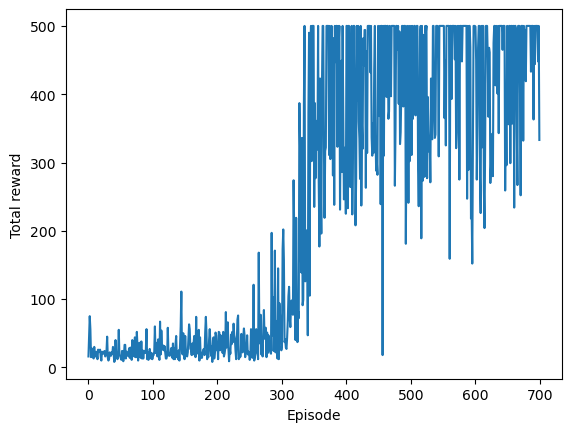

In [13]:
plt.plot(total_rewards)
plt.xlabel('Episode')
plt.ylabel('Total reward');

### 1 Stochastic Sweep 

In [14]:
# num_samples=32
# num_steps=32

# theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
# theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

# all_rewards=[]

# for t1 in tqdm(theta1_vals_viz):
#     all_rewards.append([])
#     for t2 in theta2_vals_viz:
#         all_rewards[-1].append([])
#         for i in range(num_samples):
#             pi = Pi()
#             pi.theta=nn.Parameter(torch.tensor([t1.item(), t2.item()]))
#             states, actions, rewards = run_rollout(seed=i, deterministic=False) 
#             all_rewards[-1][-1].append(np.sum(rewards).item())
# all_rewards=np.array(all_rewards)

In [15]:
# Load from disk
all_rewards = np.load(HACKIN_DIR+'/256_100_sto_2.npy')

In [16]:
avg_reward=np.mean(all_rewards, 2)
std_reward=np.std(all_rewards, 2)

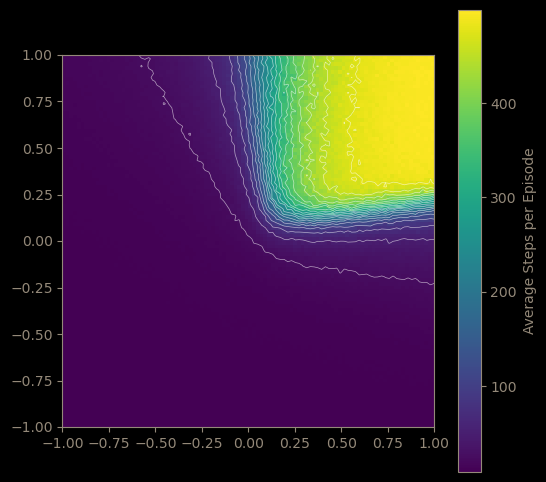

In [17]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
# im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)
cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps per Episode', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)
plt.savefig(HACKIN_DIR+'/return_landscape_stochastic_3.png', dpi=240)

## 2. Training Animation - Including 1/p

- Network training animation using REINFORCE!
- Work out visualization in single frame cell and then loop.
- Two panels, left is parameter space, right is state space
- At each step show the model's rollout on the right, and include the probability of the rollout
- In parameter space, show the return landscape, and on top draw the gradient arrows, and a thin line following learning through parameter space
- Should be able to use training configuration above

In [19]:
t1, t2 = -0.5, 0.00 #Starting point

In [20]:
#This is the style I want to use to show trajectories in parameter space. 

# k=66

# fig=plt.figure(0, (6, 6), facecolor='k')
# ax=fig.add_subplot(111, facecolor='k')

# ep=eps[k]
# obs_e, act_e = ep['obs'], ep['act']
# ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
# A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
# P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
# ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
#           extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
# ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
# ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
# m = act_e == 1
# ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
# ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
# made_it = len(act_e) == 500
# ax.scatter([ang[-1]], [angvel[-1]],
#            marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=600,
#            facecolors='none', edgecolors=('w' if made_it else RED), linewidths=2.5, zorder=5)
# ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
#         ha='left', va='top', color='w', fontsize=20)
# ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
# # ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
# # ax.set_title('State Space'); 
# style_ax(ax)
# plt.axis('off')
# plt.title(ep['prob'])

In [21]:
# %% ---- Cell A: instrumented training run ----
# ---- instrumented REINFORCE run from (t1, t2) ----
# t1, t2 are display coords (same units as the section-1 landscape extent);
# Pi is the radians-native version, so theta_native = np.degrees([t1, t2]).
# NOTE: lr=0.007 barely moves from this start (episodes die in ~12 steps -> tiny grads);
# lr=0.05 converges ~episode 1470, lr=0.1 converges faster but theta flies way off the
# landscape. After first-500 theta keeps growing (saturation), hence the stop rule.
LR = 0.05
MAX_EPISODES = 2000
STOP_AFTER_FIRST_500 = 40   # keep a few victory laps, then stop so the path stays on the landscape

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()
with torch.no_grad():
    pi.theta = nn.Parameter(torch.tensor(np.degrees([t1, t2])).float())
optimizer = optim.SGD(pi.parameters(), lr=LR)

hist = []
first_500 = None
for epi in tqdm(range(MAX_EPISODES)):
    theta_before = pi.theta.detach().numpy().copy()
    states, actions, rewards = run_rollout(seed=epi)

    T = len(rewards)
    rets = np.empty(T, dtype=np.float32)
    future_ret = 0.0
    for t in reversed(range(T)):
        future_ret = rewards[t] + gamma * future_ret
        rets[t] = future_ret
    rets = torch.tensor(rets)

    state_batch = torch.tensor(np.array(states, dtype=np.float32))
    action_batch = torch.tensor(actions)
    prob_batch = pi(state_batch)
    act_probs = prob_batch[torch.arange(T), action_batch]

    loss = -(torch.log(act_probs) * rets).sum()
    optimizer.zero_grad()
    loss.backward()
    grad = pi.theta.grad.detach().numpy().copy()   # dLoss/dtheta (native units)
    optimizer.step()

    hist.append({'obs': np.array(states), 'act': np.array(actions),
                 'R': float(np.sum(rewards)),
                 'log_prob': torch.log(act_probs).sum().item(),
                 'prob': np.exp(torch.log(act_probs).sum().item()),
                 'theta': np.radians(theta_before),   # display coords, policy that PLAYED this episode
                 'grad': grad})

    if first_500 is None and hist[-1]['R'] == 500:
        first_500 = epi
    if first_500 is not None and epi >= first_500 + STOP_AFTER_FIRST_500:
        break

R_hist = np.array([h['R'] for h in hist])
traj_disp = np.array([h['theta'] for h in hist] + [np.radians(pi.theta.detach().numpy())])
print(f'{len(hist)} episodes | first 500 @ {first_500} | '
      f'traj t1 [{traj_disp[:,0].min():+.2f}, {traj_disp[:,0].max():+.2f}] '
      f't2 [{traj_disp[:,1].min():+.2f}, {traj_disp[:,1].max():+.2f}]')

 76%|███████████████████████████▉         | 1512/2000 [00:00<00:00, 1733.81it/s]

1513 episodes | first 500 @ 1472 | traj t1 [-0.50, +0.46] t2 [+0.00, +0.75]


In [24]:
hist

[{'obs': array([[ 0.01369617, -0.00230213, -0.04590265, -0.00483472],
         [ 0.01323574,  0.01727277, -0.04686959, -0.03551522],
         [ 0.0166903 , -0.00216975, -0.05397264, -0.00776091],
         [ 0.01625635,  0.01741549, -0.05552482, -0.03868203],
         [ 0.01973945,  0.03700193, -0.06326123, -0.06964801],
         [ 0.02713983,  0.01758291, -0.07719082, -0.04243637],
         [ 0.03065641,  0.03719548, -0.0856781 , -0.07403479],
         [ 0.03809551,  0.01781137, -0.10048506, -0.04758113],
         [ 0.04165778,  0.03745003, -0.11000128, -0.07983981],
         [ 0.04914778,  0.05709456, -0.12596925, -0.11235603],
         [ 0.0605667 ,  0.07674734, -0.14844045, -0.14529532],
         [ 0.07591616,  0.09640738, -0.17749952, -0.17880923]],
        dtype=float32),
  'act': array([1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1]),
  'R': 12.0,
  'log_prob': -6.939181327819824,
  'prob': np.float64(0.0009690626171109019),
  'theta': array([-0.5,  0. ], dtype=float32),
  'grad': array([-0

In [25]:
# %% ---- Cell B: landscape precompute (reuses section-1 all_rewards) ----
# ---- landscape from section 1, same names/convention as the sweep plot cell ----
num_steps = all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
extent = np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))


|grad| = 49.249954  R = 466.0


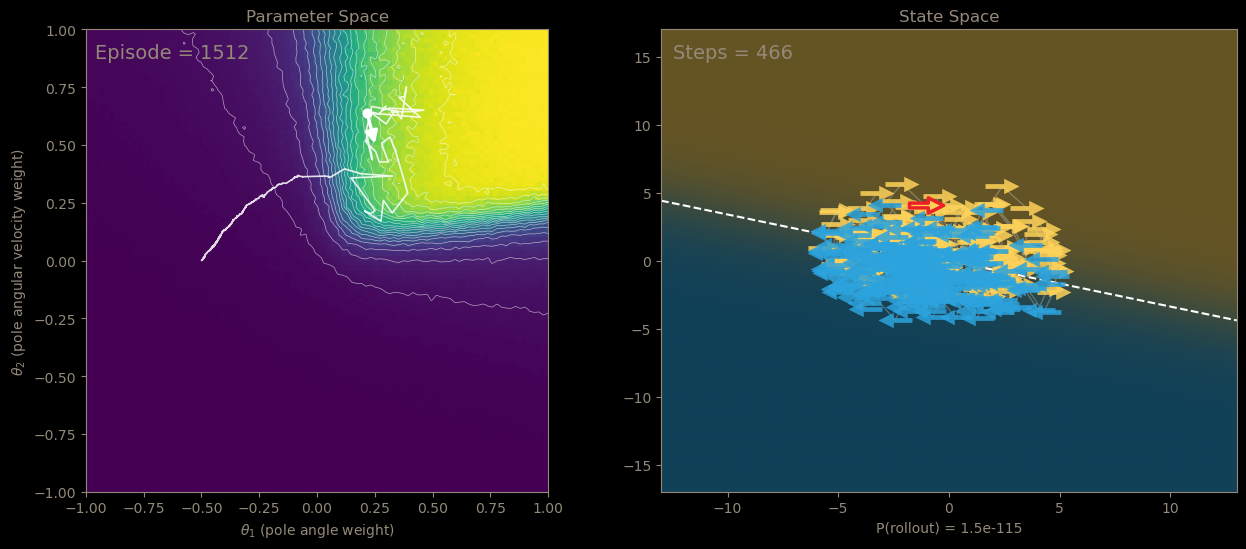

In [45]:

# %% ---- Cell C: single frame -- tweak here before the big loop ----
# ---- single frame: poke around with epi_num before running the big loop ----
epi_num = len(hist)-1
# epi_num = 15
viz_scale = 0.002        # grad magnitudes here are O(50-500) native -> small scale
min_draw_len = 0.15
max_draw_len = 0.6
ARROW_HISTORY = 0      # faded arrows for the last few episodes; 0 for current-only

ep = hist[epi_num]
th1, th2 = ep['theta']

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
axL.set_facecolor('k'); axR.set_facecolor('k')

# ---- left: parameter space -- return landscape + grad arrows + learning path ----
im = axL.imshow(avg_reward.T, origin='lower', cmap='viridis', extent=np.radians(extent), aspect='equal')
axL.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)

axL.plot(traj_disp[:epi_num+1, 0], traj_disp[:epi_num+1, 1],
         color='w', lw=1.2, alpha=0.85, zorder=4, solid_capstyle='round')

for j in range(max(0, epi_num-ARROW_HISTORY), epi_num+1):
    h = hist[j]
    g = -h['grad']                                   # descent direction (display dir == native dir)
    n = np.linalg.norm(g)
    if n < 1e-12: continue
    g_draw = (g/n) * np.clip(viz_scale*n, min_draw_len, max_draw_len)
    a = 1.0 if j == epi_num else 0.25
    axL.annotate('', xy=h['theta'] + g_draw, xytext=h['theta'],
                 arrowprops=dict(arrowstyle='-|>', color='w', lw=2.4, alpha=a, mutation_scale=18))

axL.scatter([th1], [th2], c='w', s=40, zorder=5)
axL.text(0.02, 0.97, f'Episode = {epi_num}', transform=axL.transAxes,
         ha='left', va='top', color=CHILL_BROWN, fontsize=14)
axL.set_xlabel(r'$\theta_1$ (pole angle weight)')
axL.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
axL.set_title('Parameter Space'); style_ax(axL)

# ---- right: state space -- this episode's rollout under the policy that played it ----
obs_e, act_e = ep['obs'], ep['act']
ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
P_right_grid = 1 / (1 + np.exp(-(th1 * A + th2 * V)))
axR.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
           extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
axR.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
axR.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
m = act_e == 1
axR.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
axR.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
made_it = len(act_e) == 500
axR.scatter([ang[-1]], [angvel[-1]],
            marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=600,
            facecolors='none', edgecolors=('w' if made_it else RED), linewidths=2.5, zorder=5)
axR.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=axR.transAxes,
         ha='left', va='top', color=CHILL_BROWN, fontsize=14)
axR.set_xlim(*ANG_LIM); axR.set_ylim(*VEL_LIM)
style_ax(axR)
axR.set_xlabel(f"P(rollout) = {ep['prob']:.1e}", color=CHILL_BROWN)
axR.set_title('State Space')

plt.tight_layout()
print('|grad| =', np.linalg.norm(ep['grad']), ' R =', ep['R'])

/var/folders/bl/nrs5y8qx2jb60s7g3xjdsr040000gn/T/ipykernel_14438/2861943032.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')


<Figure size 640x480 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

...

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

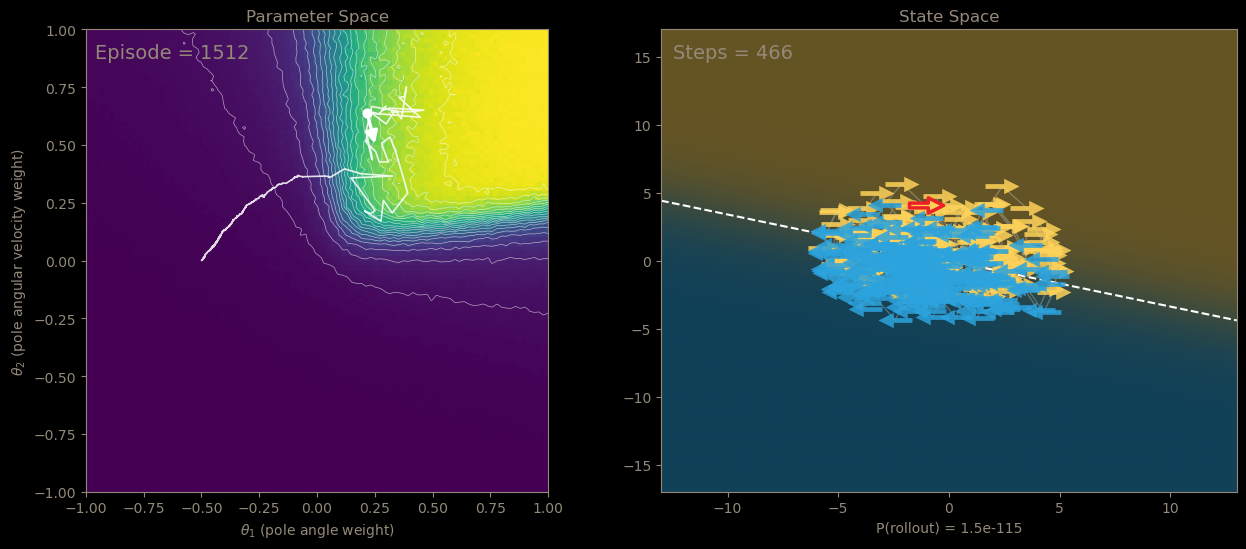

In [49]:
save_dir = HACKIN_DIR + '/rl_training_1'
os.makedirs(save_dir, exist_ok=True)


# %% ---- Cell C: single frame -- tweak here before the big loop ----
# ---- single frame: poke around with epi_num before running the big loop ----
# epi_num = len(hist)-1
# epi_num = 15

for epi_num in tqdm(range(len(hist))):
    viz_scale = 0.002        # grad magnitudes here are O(50-500) native -> small scale
    min_draw_len = 0.15
    max_draw_len = 0.6
    ARROW_HISTORY = 0      # faded arrows for the last few episodes; 0 for current-only
    
    ep = hist[epi_num]
    th1, th2 = ep['theta']
    
    plt.clf()
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
    axL.set_facecolor('k'); axR.set_facecolor('k')
    
    # ---- left: parameter space -- return landscape + grad arrows + learning path ----
    im = axL.imshow(avg_reward.T, origin='lower', cmap='viridis', extent=np.radians(extent), aspect='equal')
    axL.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)
    
    axL.plot(traj_disp[:epi_num+1, 0], traj_disp[:epi_num+1, 1],
             color='w', lw=1.2, alpha=0.85, zorder=4, solid_capstyle='round')
    
    for j in range(max(0, epi_num-ARROW_HISTORY), epi_num+1):
        h = hist[j]
        g = -h['grad']                                   # descent direction (display dir == native dir)
        n = np.linalg.norm(g)
        if n < 1e-12: continue
        g_draw = (g/n) * np.clip(viz_scale*n, min_draw_len, max_draw_len)
        a = 1.0 if j == epi_num else 0.25
        axL.annotate('', xy=h['theta'] + g_draw, xytext=h['theta'],
                     arrowprops=dict(arrowstyle='-|>', color='w', lw=2.4, alpha=a, mutation_scale=18))
    
    axL.scatter([th1], [th2], c='w', s=40, zorder=5)
    axL.text(0.02, 0.97, f'Episode = {epi_num}', transform=axL.transAxes,
             ha='left', va='top', color=CHILL_BROWN, fontsize=14)
    axL.set_xlabel(r'$\theta_1$ (pole angle weight)')
    axL.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
    axL.set_title('Parameter Space'); style_ax(axL)
    
    # ---- right: state space -- this episode's rollout under the policy that played it ----
    obs_e, act_e = ep['obs'], ep['act']
    ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
    P_right_grid = 1 / (1 + np.exp(-(th1 * A + th2 * V)))
    axR.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
               extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    axR.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    axR.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
    m = act_e == 1
    axR.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
    axR.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
    made_it = len(act_e) == 500
    axR.scatter([ang[-1]], [angvel[-1]],
                marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=600,
                facecolors='none', edgecolors=('w' if made_it else RED), linewidths=2.5, zorder=5)
    axR.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=axR.transAxes,
             ha='left', va='top', color=CHILL_BROWN, fontsize=14)
    axR.set_xlim(*ANG_LIM); axR.set_ylim(*VEL_LIM)
    style_ax(axR)
    axR.set_xlabel(f"P(rollout) = {ep['prob']:.1e}", color=CHILL_BROWN)
    axR.set_title('State Space')
    
    plt.tight_layout()
    # print('|grad| =', np.linalg.norm(ep['grad']), ' R =', ep['R'])
    plt.savefig(save_dir+'/rl_training_1_'+str(epi_num).zfill(3)+'.png')

### 3. Training Animation - Remove 1/p scaling

In [50]:
# %% ---- Cell A (section 3): instrumented run WITHOUT the 1/p correction ----
# Same as section 2's Cell A except the loss drops the log:
#     loss = -(act_probs * rets).sum()        [was  -(log(act_probs) * rets).sum()]
# i.e. we ascend grad(sum p_t * R) directly instead of grad(sum log p_t * R) -- no
# 1/p reweighting of rare rollouts.
#
# What happens from (-0.5, 0): training goes BACKWARDS. The already-likely (bad)
# actions get reinforced hardest, so theta drifts down-left away from the reward
# peak and returns degrade (~12 -> ~9.7 steps). At LR=0.2 the path slides to the
# left edge of the landscape and exits at ~episode 2005 -- hence the stop rule.
# (LR needs to be ~4-40x larger than the log version: without 1/p every grad
# carries p*(1-p) sigmoid factors, so |grad| is ~0.1 here vs ~10-100 with the log.)
LR = 0.2
MAX_EPISODES = 3000

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()
with torch.no_grad():
    pi.theta = nn.Parameter(torch.tensor(np.degrees([t1, t2])).float())
optimizer = optim.SGD(pi.parameters(), lr=LR)

hist = []
for epi in tqdm(range(MAX_EPISODES)):
    theta_before = pi.theta.detach().numpy().copy()
    states, actions, rewards = run_rollout(seed=epi)

    T = len(rewards)
    rets = np.empty(T, dtype=np.float32)
    future_ret = 0.0
    for t in reversed(range(T)):
        future_ret = rewards[t] + gamma * future_ret
        rets[t] = future_ret
    rets = torch.tensor(rets)

    state_batch = torch.tensor(np.array(states, dtype=np.float32))
    action_batch = torch.tensor(actions)
    prob_batch = pi(state_batch)
    act_probs = prob_batch[torch.arange(T), action_batch]

    loss = -(act_probs * rets).sum()          # <-- no log: no 1/p correction
    optimizer.zero_grad()
    loss.backward()
    grad = pi.theta.grad.detach().numpy().copy()   # dLoss/dtheta (native units)
    optimizer.step()

    hist.append({'obs': np.array(states), 'act': np.array(actions),
                 'R': float(np.sum(rewards)),
                 'log_prob': torch.log(act_probs).sum().item(),
                 'prob': np.exp(torch.log(act_probs).sum().item()),
                 'theta': np.radians(theta_before),   # display coords, policy that PLAYED this episode
                 'grad': grad})

    # stop once theta leaves the plotted landscape (it never converges -- it runs away)
    if np.abs(np.radians(pi.theta.detach().numpy())).max() > 1.0:
        print(f'left the landscape at episode {epi}')
        break

R_hist = np.array([h['R'] for h in hist])
traj_disp = np.array([h['theta'] for h in hist] + [np.radians(pi.theta.detach().numpy())])
print(f'{len(hist)} episodes | R first50 {R_hist[:50].mean():.1f} -> last50 {R_hist[-50:].mean():.1f} | '
      f'traj t1 [{traj_disp[:,0].min():+.2f}, {traj_disp[:,0].max():+.2f}] '
      f't2 [{traj_disp[:,1].min():+.2f}, {traj_disp[:,1].max():+.2f}]')

 67%|████████████████████████▋            | 2005/3000 [00:00<00:00, 3233.46it/s]

left the landscape at episode 2005
2006 episodes | R first50 11.9 -> last50 9.7 | traj t1 [-1.00, -0.50] t2 [-0.47, +0.00]


  1%|▍                                        | 19/2006 [00:02<03:49,  8.67it/s]/var/folders/bl/nrs5y8qx2jb60s7g3xjdsr040000gn/T/ipykernel_14438/83122460.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
100%|███████████████████████████████████████| 2006/2006 [04:28<00:00,  7.47it/s]


<Figure size 640x480 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

...

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

<Figure size 1300x560 with 0 Axes>

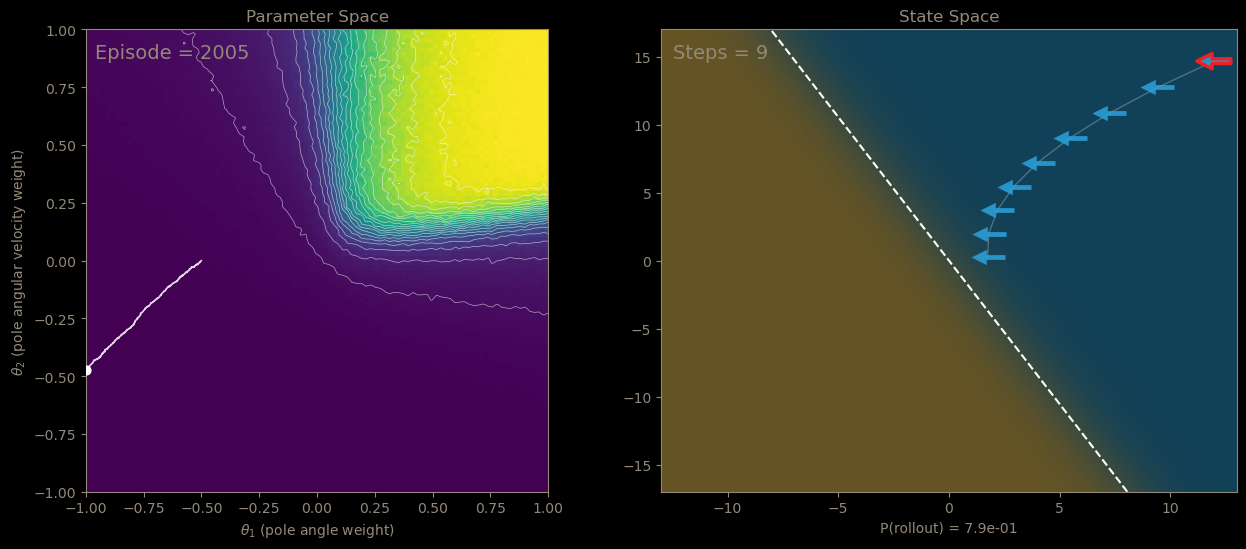

In [51]:
save_dir = HACKIN_DIR + '/rl_training_2'
os.makedirs(save_dir, exist_ok=True)


# %% ---- Cell C: single frame -- tweak here before the big loop ----
# ---- single frame: poke around with epi_num before running the big loop ----
# epi_num = len(hist)-1
# epi_num = 15

for epi_num in tqdm(range(len(hist))):
    viz_scale = 0.002        # grad magnitudes here are O(50-500) native -> small scale
    min_draw_len = 0.15
    max_draw_len = 0.6
    ARROW_HISTORY = 0      # faded arrows for the last few episodes; 0 for current-only
    
    ep = hist[epi_num]
    th1, th2 = ep['theta']
    
    plt.clf()
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.6), facecolor='k')
    axL.set_facecolor('k'); axR.set_facecolor('k')
    
    # ---- left: parameter space -- return landscape + grad arrows + learning path ----
    im = axL.imshow(avg_reward.T, origin='lower', cmap='viridis', extent=np.radians(extent), aspect='equal')
    axL.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)
    
    axL.plot(traj_disp[:epi_num+1, 0], traj_disp[:epi_num+1, 1],
             color='w', lw=1.2, alpha=0.85, zorder=4, solid_capstyle='round')
    
    for j in range(max(0, epi_num-ARROW_HISTORY), epi_num+1):
        h = hist[j]
        g = -h['grad']                                   # descent direction (display dir == native dir)
        n = np.linalg.norm(g)
        if n < 1e-12: continue
        g_draw = (g/n) * np.clip(viz_scale*n, min_draw_len, max_draw_len)
        a = 1.0 if j == epi_num else 0.25
        axL.annotate('', xy=h['theta'] + g_draw, xytext=h['theta'],
                     arrowprops=dict(arrowstyle='-|>', color='w', lw=2.4, alpha=a, mutation_scale=18))
    
    axL.scatter([th1], [th2], c='w', s=40, zorder=5)
    axL.text(0.02, 0.97, f'Episode = {epi_num}', transform=axL.transAxes,
             ha='left', va='top', color=CHILL_BROWN, fontsize=14)
    axL.set_xlabel(r'$\theta_1$ (pole angle weight)')
    axL.set_ylabel(r'$\theta_2$ (pole angular velocity weight)')
    axL.set_title('Parameter Space'); style_ax(axL)
    
    # ---- right: state space -- this episode's rollout under the policy that played it ----
    obs_e, act_e = ep['obs'], ep['act']
    ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
    P_right_grid = 1 / (1 + np.exp(-(th1 * A + th2 * V)))
    axR.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
               extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    axR.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    axR.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
    m = act_e == 1
    axR.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
    axR.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
    made_it = len(act_e) == 500
    axR.scatter([ang[-1]], [angvel[-1]],
                marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=600,
                facecolors='none', edgecolors=('w' if made_it else RED), linewidths=2.5, zorder=5)
    axR.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=axR.transAxes,
             ha='left', va='top', color=CHILL_BROWN, fontsize=14)
    axR.set_xlim(*ANG_LIM); axR.set_ylim(*VEL_LIM)
    style_ax(axR)
    axR.set_xlabel(f"P(rollout) = {ep['prob']:.1e}", color=CHILL_BROWN)
    axR.set_title('State Space')
    
    plt.tight_layout()
    # print('|grad| =', np.linalg.norm(ep['grad']), ' R =', ep['R'])
    plt.savefig(save_dir+'/rl_training_1_'+str(epi_num).zfill(3)+'.png')